# Homework 2: Natural language inference (NLI)

# Import Libraries

In [ ]:
# !pip install accelerate -U
# !pip install datasets
# !pip install jsonlines

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torch import cuda
import jsonlines
import time

import random

import torch
import torch.nn as nn
from datasets import load_dataset, load_metric
from sklearn.metrics import classification_report, confusion_matrix
from transformers import pipeline
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaModel, RobertaTokenizer

from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EvalPrediction,
    Trainer,
    TrainingArguments,
    set_seed,
)

set_seed(42)

import argparse

import warnings
warnings.filterwarnings("ignore")

# Exploratory Data Analysis (EDA)

## Fever Dataset

In [3]:
# Upload FEVER dataset
fever_data = load_dataset("tommasobonomo/sem_augmented_fever_nli")

Generating train split:   0%|          | 0/51086 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2288 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2287 [00:00<?, ? examples/s]

In [4]:
fever_data

DatasetDict({
    train: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 51086
    })
    validation: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2288
    })
    test: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
        num_rows: 2287
    })
})

In [ ]:
print("NLI FEVER Train-Set Premise Example: \n", fever_data['train']['premise'][0], "\n")
print("NLI FEVER Train-Set Hypothesis Example: \n", fever_data['train']['hypothesis'][0], "\n")
print("NLI FEVER Train-Set Label Example: \n", fever_data['train']['label'][0])

NLI FEVER Train-Set Premise Example: 
 Roman Atwood . He is best known for his vlogs , where he posts updates about his life on a daily basis . His vlogging channel , `` RomanAtwoodVlogs '' , has a total of 3.3 billion views and 11.9 million subscribers . He also has another YouTube channel called `` RomanAtwood '' , where he posts pranks . 

NLI FEVER Train-Set Hypothesis Example: 
 Roman Atwood is a content creator. 

NLI FEVER Train-Set Label Example: 
 ENTAILMENT


In [ ]:
# Previw of Validation-Set in FEVER
pd.DataFrame(fever_data['validation']).head()

,id,premise,hypothesis,label,wsd,srl
0,91198,Colin Kaepernick . Kaepernick began his profes...,Colin Kaepernick became a starting quarterback...,NEUTRAL,"{'premise': [{'index': 0, 'text': 'Colin', 'po...","{'premise': {'tokens': [{'index': 0, 'rawText'..."
1,181634,Mogadishu ( [ ˌmɔːɡəˈdiːʃuː ] Muqdisho [ mʉqdɪ...,There is a capital called Mogadishu.,ENTAILMENT,"{'premise': [{'index': 0, 'text': 'Mogadishu',...","{'premise': {'tokens': [{'index': 0, 'rawText'..."
2,140846,Shooter (2007 film) . The film follows Force R...,Shooter is about an expert marksman who tries ...,NEUTRAL,"{'premise': [{'index': 0, 'text': 'Shooter', '...","{'premise': {'tokens': [{'index': 0, 'rawText'..."
3,167997,"Sir Donald George `` Don '' Bradman , AC ( 27 ...",Don Bradman retired from soccer.,NEUTRAL,"{'premise': [{'index': 0, 'text': 'Sir', 'pos'...","{'premise': {'tokens': [{'index': 0, 'rawText'..."
4,140764,Boardwalk is a 1979 American drama film writte...,Janet Leigh was incapable of writing.,CONTRADICTION,"{'premise': [{'index': 0, 'text': 'Boardwalk',...","{'premise': {'tokens': [{'index': 0, 'rawText'..."


In [6]:
def plot_label_counts(dataset, split_name):
  # Calculate labels count and label percentages
  dataset = pd.DataFrame(dataset)
  label_counts = dataset['label'].value_counts()
  print(label_counts, "\n")
  label_percentages = label_counts / label_counts.sum() * 100

  # Plot the bar chart
  plt.figure(figsize = (8, 6))
  plt.style.use("seaborn")
  label_counts.plot(kind = 'bar', color=["#007BA7", "#99CBFF", "#4b0082"])
  plt.title(f'Task Labels Count for {split_name}')
  plt.xlabel('Labels')
  plt.ylabel('Count')
  plt.xticks(rotation = 0)
  plt.grid(axis = 'y')

  # Add percentage above bars
  for i, (count, percentage) in enumerate(zip(label_counts, label_percentages)):
        plt.text(i, count + max(label_counts) * 0.01, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()


def plot_distro_sentence_len(dataset, split_name):
  # Compute the sentences length
  dataset['premise_length'] = dataset['premise'].apply(len)
  dataset['hypothesis_length'] = dataset['hypothesis'].apply(len)

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
  plt.style.use("seaborn")

  # Generate Premise histogram
  axes[0].hist(dataset['premise_length'], bins=50, color='skyblue', edgecolor='black')
  axes[0].set_title('Premise Length')
  axes[0].set_xlabel('Sentence Length')
  axes[0].set_ylabel('Frequency')

  # Generate Hypothesis histogram
  axes[1].hist(dataset['hypothesis_length'], bins=50, color='salmon', edgecolor='black')
  axes[1].set_title('Hypothesis Length')
  axes[1].set_xlabel('Sentence Length')
  axes[1].set_ylabel('Frequency')

  # Plot the histograms
  fig.suptitle(f"Distribution of Sentence Lengths in {split_name}", fontsize=16)
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.show()

label
ENTAILMENT       31128
CONTRADICTION    12331
NEUTRAL           7627
Name: count, dtype: int64 



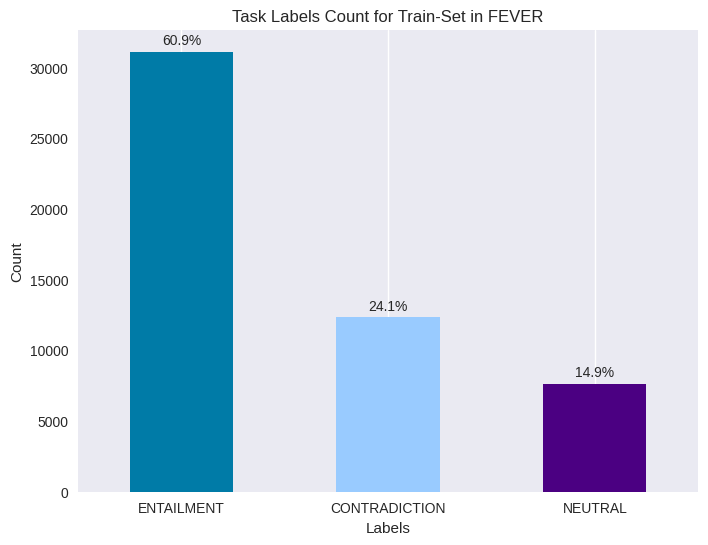

In [ ]:
plot_label_counts(fever_data['train'], 'Train-Set in FEVER')

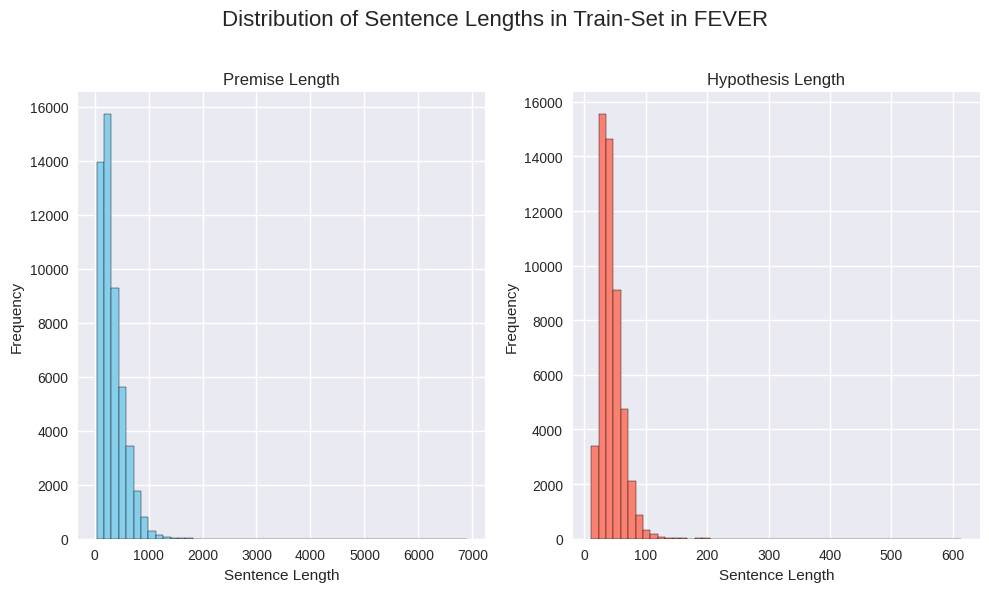

In [ ]:
plot_distro_sentence_len(pd.DataFrame(fever_data['train']), 'Train-Set in FEVER')

label
ENTAILMENT       821
CONTRADICTION    775
NEUTRAL          692
Name: count, dtype: int64 



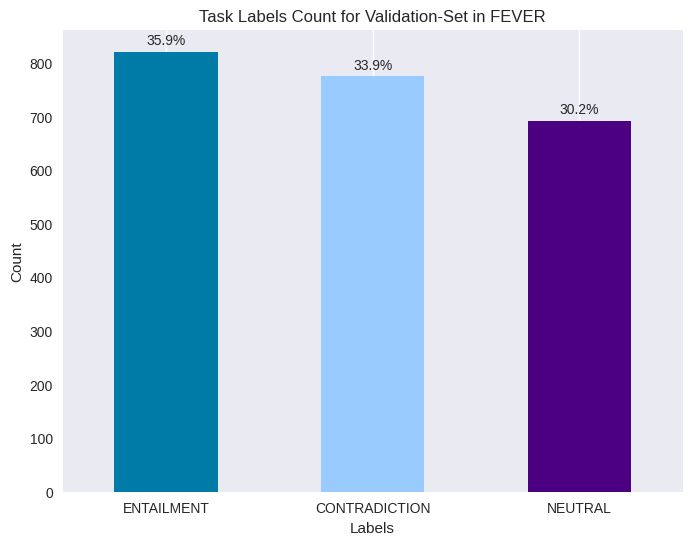

In [ ]:
plot_label_counts(fever_data['validation'], 'Validation-Set in FEVER')

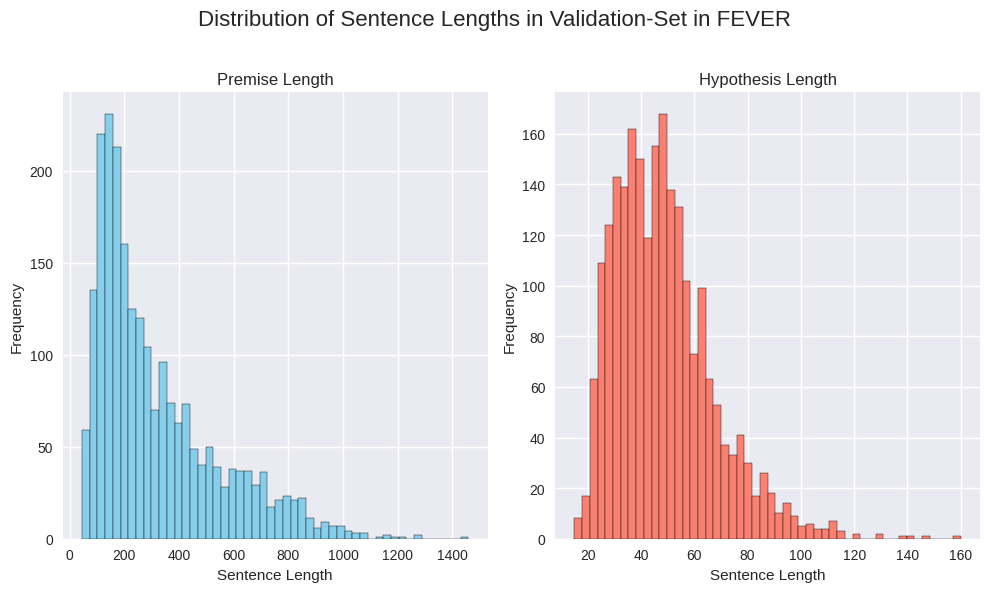

In [ ]:
plot_distro_sentence_len(pd.DataFrame(fever_data['validation']), 'Validation-Set in FEVER')

label
CONTRADICTION    812
ENTAILMENT       792
NEUTRAL          683
Name: count, dtype: int64 



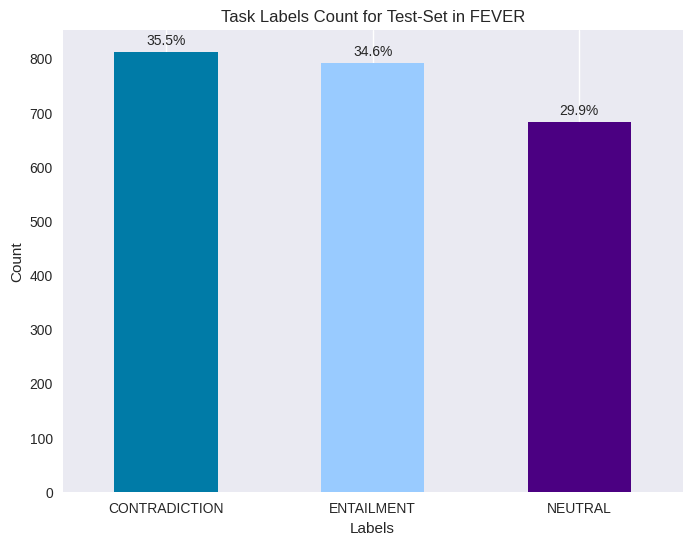

In [ ]:
plot_label_counts(fever_data['test'], 'Test-Set in FEVER')

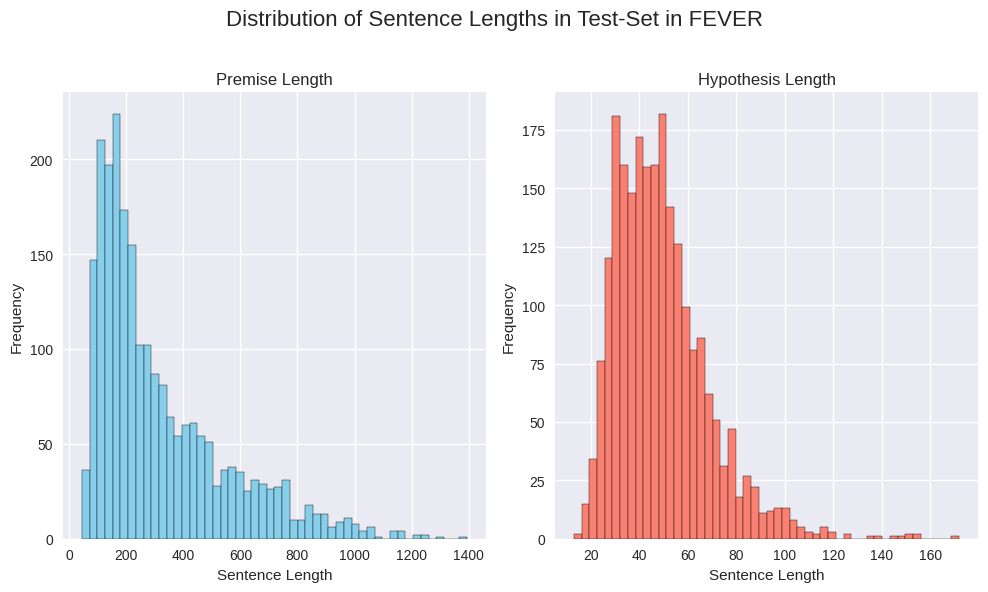

In [ ]:
plot_distro_sentence_len(pd.DataFrame(fever_data['test']), 'Test-Set in FEVER')

## Adversarial Dataset

In [5]:
# Upload Adversarial dataset
adversarial_test_set = load_dataset("iperbole/adversarial_fever_nli")

Generating test split:   0%|          | 0/337 [00:00<?, ? examples/s]

In [ ]:
adversarial_test_set

DatasetDict({
    test: Dataset({
        features: ['part', 'cid', 'premise', 'hypothesis', 'label'],
        num_rows: 337
    })
})

In [ ]:
print("Adversarial Test-Set Premise Example: \n", adversarial_test_set['test']['premise'][0], "\n")
print("Adversarial Test-Set Hypothesis Example: \n", adversarial_test_set['test']['hypothesis'][0], "\n")
print("Adversarial Test-Set Label Example: \n", adversarial_test_set['test']['label'][0])

Adversarial Test-Set Premise Example: 
 Johnny Galecki . He is known for playing David Healy in the ABC sitcom Roseanne from 1992 -- 1997 and Dr. Leonard Hofstadter in the CBS sitcom The Big Bang Theory since 2007 . 

Adversarial Test-Set Hypothesis Example: 
 The number of sitcoms from France in which Johnny Galecki has played a character is greater or equal to 2 

Adversarial Test-Set Label Example: 
 NEUTRAL


label
CONTRADICTION    116
ENTAILMENT       111
NEUTRAL          110
Name: count, dtype: int64 



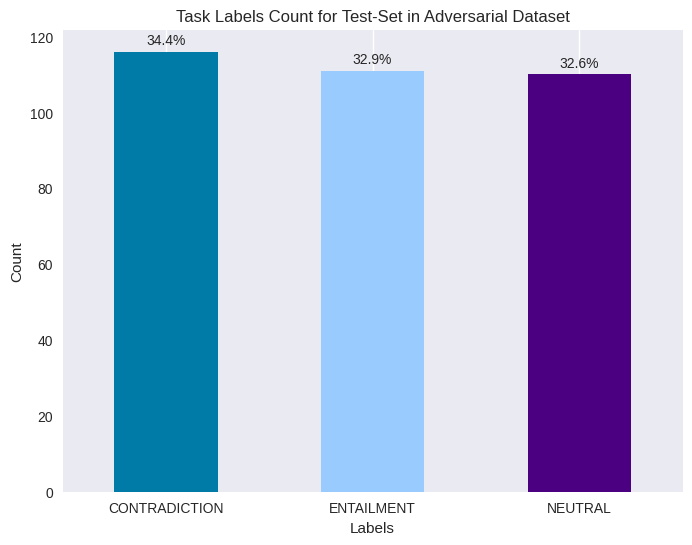

In [ ]:
plot_label_counts(adversarial_test_set['test'], 'Test-Set in Adversarial Dataset')

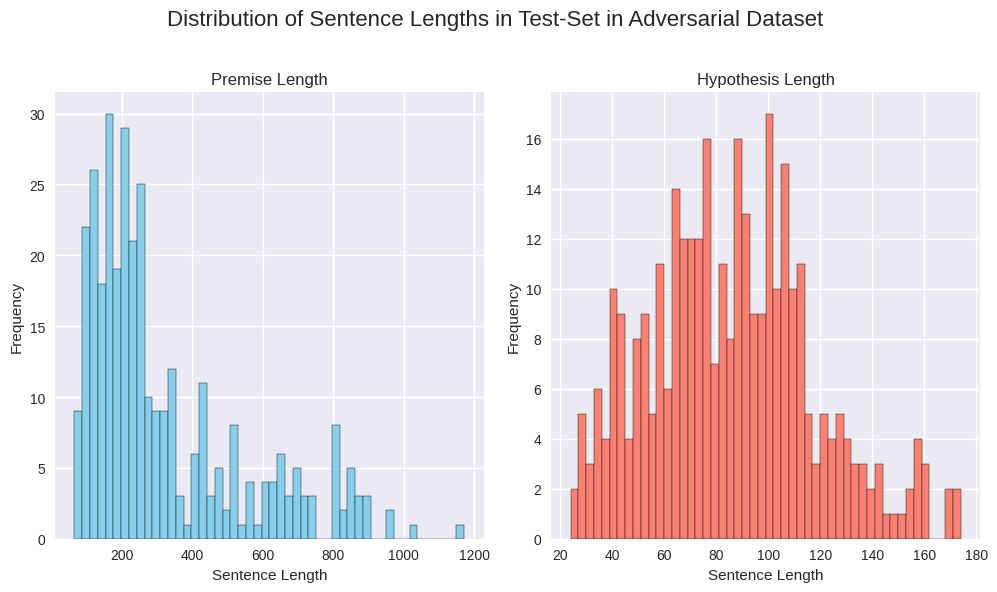

In [ ]:
plot_distro_sentence_len(pd.DataFrame(adversarial_test_set['test']), 'Test-Set in Adversarial Dataset')

In [ ]:
# Previw of Adversarial Dataset
pd.DataFrame(adversarial_test_set['test']).head()

,part,cid,premise,hypothesis,label
0,manual_adversarial,58846,Johnny Galecki . He is known for playing David...,The number of sitcoms from France in which Joh...,NEUTRAL
1,manual_adversarial,172460,Matteo Renzi ( [ matˈtɛːo ˈrɛntsi ] ; born 11 ...,Matteo Renzi was the president of the Council ...,ENTAILMENT
2,manual_adversarial,181201,Southpaw is a 2015 American sports drama film ...,Among the movies that premiered 13 years befor...,CONTRADICTION
3,manual_adversarial,174024,Pink Floyd . The final Pink Floyd studio album...,counting Pink Floyd's albums from last to firs...,CONTRADICTION
4,manual_adversarial,118068,Beatles Day . This day is considered one of th...,Beatles Day was celebrated 20 years before 2024,CONTRADICTION


# Performance Evaluation using Original Data

## DeBERTa V3 model

In [4]:
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
model_name = "microsoft/deberta-v3-small"

model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                          ignore_mismatched_sizes = True,
                                                          output_attentions = False,
                                                          output_hidden_states = False,
                                                          num_labels = 3)

tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
model

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): StableDropout()
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-5): 6 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): StableDropout()
              (dropout): StableDropout()
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=T

## Data Preparation

In [7]:
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

In [8]:
def map_labels(example):
  label_map = {'ENTAILMENT': 0, 'CONTRADICTION': 1, 'NEUTRAL': 2}
  example['label'] = label_map[example['label']]
  return example

In [ ]:
# Map FEVER Dataset labels
fever_data['train'] = fever_data['train'].map(map_labels)
fever_data['validation'] = fever_data['validation'].map(map_labels)
fever_data['test'] = fever_data['test'].map(map_labels)

# Map Adversarial Dataset labels
adversarial_test_set['test'] = adversarial_test_set['test'].map(map_labels)

In [9]:
def tokenize_function(examples):
  inputs = ["[CLS] " + p + " [SEP] " + h for p, h in zip(examples['premise'], examples['hypothesis'])]
  tokens = tokenizer(inputs,
                  padding = True,
                  truncation = True,
                  max_length = 400)
  return tokens

In [ ]:
# Tokenize FEVER Dataset senteces
tokenized_fever_data = fever_data.map(tokenize_function, batched = True)

# Tokenize Adversarial Dataset senteces
tokenized_adversarial_test_data = adversarial_test_set.map(tokenize_function, batched=True)

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

In [ ]:
tokenized_fever_data

DatasetDict({
    train: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 51086
    })
    validation: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2288
    })
    test: Dataset({
        features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2287
    })
})

## Train

In [10]:
def compute_metrics(eval_pred):
    load_accuracy = load_metric("accuracy", trust_remote_code=True)
    load_f1 = load_metric("f1", trust_remote_code=True)
    load_precision = load_metric("precision", trust_remote_code=True)
    load_recall = load_metric("recall", trust_remote_code=True)

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Compute metrics
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels, average='weighted')["f1"]
    precision = load_precision.compute(predictions=predictions, references=labels, average='weighted')["precision"]
    recall = load_recall.compute(predictions=predictions, references=labels, average='weighted')["recall"]

    # Print classification report
    classification_rep = classification_report(labels, predictions)
    print(classification_rep)

    # Compute confusion matrix
    cm = confusion_matrix(labels, predictions)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
                xticklabels=range(len(cm)),
                yticklabels=range(len(cm)))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return {"accuracy": accuracy, "f1": f1, "precision": precision, "recall": recall}

In [11]:
# Parameters initialization
batch_size = 32
learning_rate = 1e-5
weight_decay = 0.001
epochs = 1

In [12]:
training_args = TrainingArguments(output_dir = "training_dir",
                                  num_train_epochs = epochs,
                                  per_device_train_batch_size = batch_size,
                                  warmup_steps = 500,
                                  weight_decay = weight_decay,
                                  save_strategy = "no",
                                  save_total_limit = 5,
                                  learning_rate = learning_rate,
                                  )

In [ ]:
trainer = Trainer(model = model,
                  args = training_args,
                  train_dataset = tokenized_fever_data["train"],
                  eval_dataset = tokenized_fever_data["validation"],
                  tokenizer = tokenizer,
                  data_collator = data_collator,
                  compute_metrics = compute_metrics,
                  )

In [ ]:
# Train the model using original data
trainer.train()

Step,Training Loss
500,0.965700
1000,0.530900
1500,0.441800


TrainOutput(global_step=1597, training_loss=0.6325112081872872, metrics={'train_runtime': 2361.1764, 'train_samples_per_second': 21.636, 'train_steps_per_second': 0.676, 'total_flos': 5287180676299200.0, 'train_loss': 0.6325112081872872, 'epoch': 1.0})

## Test and Evaluation

              precision    recall  f1-score   support

           0       0.71      0.93      0.81       821
           1       0.75      0.75      0.75       775
           2       0.70      0.44      0.54       692

    accuracy                           0.72      2288
   macro avg       0.72      0.71      0.70      2288
weighted avg       0.72      0.72      0.71      2288



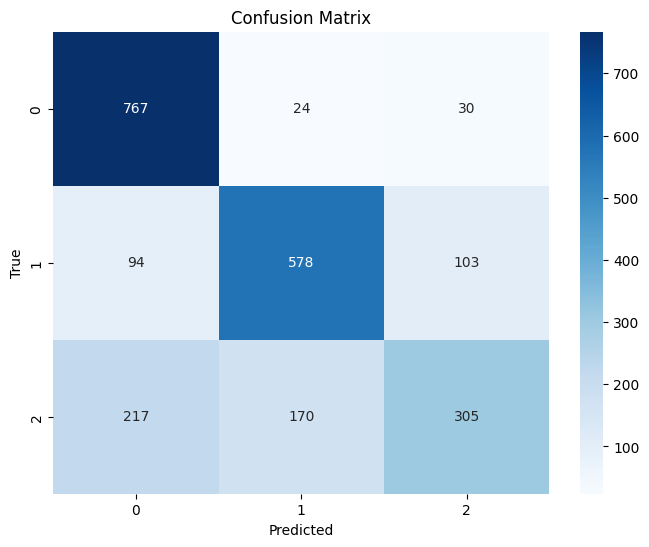

{'eval_loss': 0.7884781956672668,
 'eval_accuracy': 0.7211538461538461,
 'eval_f1': 0.7062399155526796,
 'eval_precision': 0.7195201245170457,
 'eval_recall': 0.7211538461538461,
 'eval_runtime': 36.0807,
 'eval_samples_per_second': 63.413,
 'eval_steps_per_second': 7.927,
 'epoch': 1.0}

In [ ]:
# FEVER Validation-Set Evaluation using original data
trainer.evaluate()

              precision    recall  f1-score   support

           0       0.71      0.92      0.80       792
           1       0.71      0.72      0.71       812
           2       0.65      0.41      0.50       683

    accuracy                           0.70      2287
   macro avg       0.69      0.68      0.67      2287
weighted avg       0.69      0.70      0.68      2287



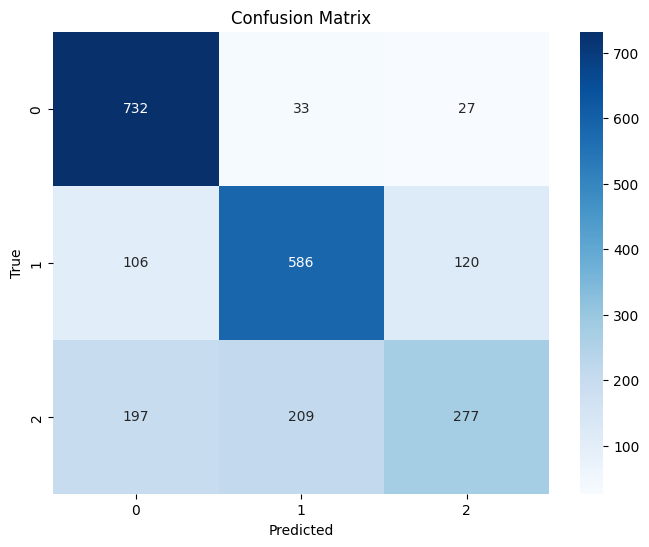

{'eval_loss': 0.8351636528968811,
 'eval_accuracy': 0.6974202011368605,
 'eval_f1': 0.6806872813013493,
 'eval_precision': 0.6913076727662629,
 'eval_recall': 0.6974202011368605,
 'eval_runtime': 32.4763,
 'eval_samples_per_second': 70.421,
 'eval_steps_per_second': 8.806,
 'epoch': 1.0}

In [ ]:
# FEVER Test-Set Evaluation using original data
trainer.evaluate(eval_dataset = tokenized_fever_data['test'])

              precision    recall  f1-score   support

           0       0.47      0.57      0.51       111
           1       0.48      0.60      0.53       116
           2       0.68      0.35      0.46       110

    accuracy                           0.51       337
   macro avg       0.54      0.51      0.50       337
weighted avg       0.54      0.51      0.50       337



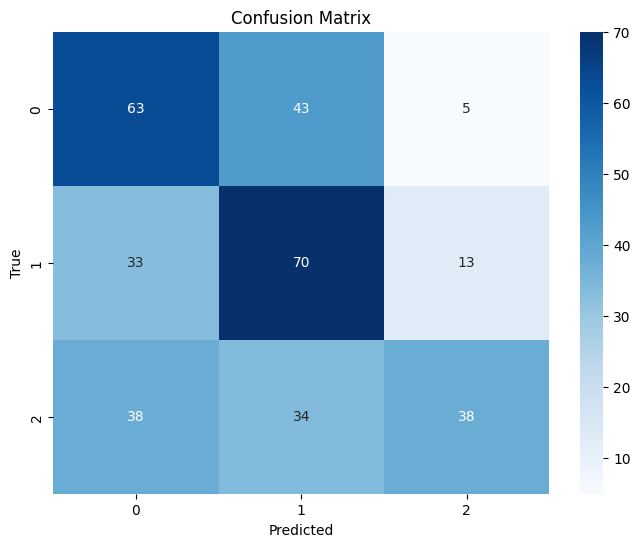

{'eval_loss': 1.3667525053024292,
 'eval_accuracy': 0.5074183976261127,
 'eval_f1': 0.5020659035563935,
 'eval_precision': 0.5402597019143368,
 'eval_recall': 0.5074183976261127,
 'eval_runtime': 5.9238,
 'eval_samples_per_second': 56.889,
 'eval_steps_per_second': 7.259,
 'epoch': 1.0}

In [ ]:
# Adversarial Test-Set Evaluation using original data
trainer.evaluate(eval_dataset = tokenized_adversarial_test_data['test'])

# Performance Evaluation using Augmented Data

## Data Augmentation with Adversarial Examples

In [2]:
# Upload FEVER Augmented dataset
fever_data_augmented = load_dataset("tommasobonomo/sem_augmented_fever_nli")

In [3]:
# Upload Adversarial dataset
adversarial_test_set = load_dataset("iperbole/adversarial_fever_nli")

In [16]:
def add_adversarial_examples(file_name):
  ids = fever_data_augmented['train']['id']
  max_id = max(ids)
  num = 0

  with jsonlines.open(file_name) as reader:
    for dic in reader:
      new_id = int(max_id) + 1
      dic['id'] = str(new_id)
      fever_data_augmented['train'] = fever_data_augmented['train'].add_item(dic)
      num += 1

  print(f"Added {num} examples to the Train-Set \n")
  return fever_data_augmented['train']

In [17]:
add_adversarial_examples("/content/neutral_adversarial_examples_first_approach.jsonl")

Added 4027 examples to the Train-Set 



Dataset({
    features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
    num_rows: 55113
})

In [18]:
add_adversarial_examples("/content/neutral_adversarial_examples_second_approach.jsonl")

Added 312 examples to the Train-Set 



Dataset({
    features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
    num_rows: 55425
})

In [19]:
add_adversarial_examples("/content/contradiction_adversarial_examples_first_approach.jsonl")

Added 715 examples to the Train-Set 



Dataset({
    features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
    num_rows: 56140
})

In [20]:
add_adversarial_examples("/content/contradiction_adversarial_examples_second_approach.jsonl")

Added 353 examples to the Train-Set 



Dataset({
    features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
    num_rows: 56493
})

In [21]:
add_adversarial_examples("/content/contradiction_adversarial_examples_third_approach.jsonl")

Added 2835 examples to the Train-Set 



Dataset({
    features: ['id', 'premise', 'hypothesis', 'label', 'wsd', 'srl'],
    num_rows: 59328
})

### Data Preparation

In [22]:
# Map FEVER Augmented Dataset labels
fever_data_augmented['train'] = fever_data_augmented['train'].map(map_labels)
fever_data_augmented['validation'] = fever_data_augmented['validation'].map(map_labels)
fever_data_augmented['test'] = fever_data_augmented['test'].map(map_labels)

# Map Adversarial Dataset labels
adversarial_test_set['test'] = adversarial_test_set['test'].map(map_labels)

Map:   0%|          | 0/59328 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

Map:   0%|          | 0/2287 [00:00<?, ? examples/s]

Map:   0%|          | 0/337 [00:00<?, ? examples/s]

In [23]:
# Tokenize FEVER Augmented Dataset senteces
tokenized_fever_data_augmented = fever_data_augmented.map(tokenize_function, batched = True)

# Tokenize Adversarial Dataset senteces
tokenized_adversarial_test_data = adversarial_test_set.map(tokenize_function, batched=True)

Map:   0%|          | 0/59328 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

Map:   0%|          | 0/2287 [00:00<?, ? examples/s]

Map:   0%|          | 0/337 [00:00<?, ? examples/s]

### Test

In [24]:
trainer = Trainer(model = model,
                  args = training_args,
                  train_dataset = tokenized_fever_data_augmented["train"],  # augmented data
                  eval_dataset = tokenized_fever_data_augmented["validation"], # aumented data
                  tokenizer = tokenizer,
                  data_collator = data_collator,
                  compute_metrics = compute_metrics,
                  )

In [25]:
# Train the model using augmented data
trainer.train()

Step,Training Loss
500,0.937800
1000,0.433900
1500,0.372600


TrainOutput(global_step=1854, training_loss=0.5371088400370609, metrics={'train_runtime': 2773.6523, 'train_samples_per_second': 21.39, 'train_steps_per_second': 0.668, 'total_flos': 6140192130201600.0, 'train_loss': 0.5371088400370609, 'epoch': 1.0})

### Test and Evaluation

              precision    recall  f1-score   support

           0       0.75      0.94      0.83       821
           1       0.79      0.78      0.78       775
           2       0.73      0.52      0.61       692

    accuracy                           0.76      2288
   macro avg       0.76      0.75      0.74      2288
weighted avg       0.76      0.76      0.75      2288



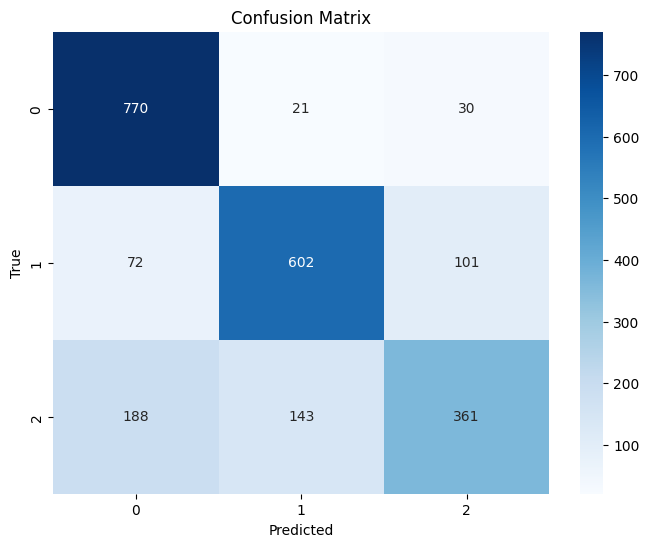

{'eval_loss': 0.733063280582428,
 'eval_accuracy': 0.7574300699300699,
 'eval_f1': 0.7476195083425682,
 'eval_precision': 0.7563716591270461,
 'eval_recall': 0.7574300699300699,
 'eval_runtime': 31.8351,
 'eval_samples_per_second': 71.87,
 'eval_steps_per_second': 8.984,
 'epoch': 1.0}

In [27]:
# FEVER Validation-Set Evaluation using augmented data
trainer.evaluate()

              precision    recall  f1-score   support

           0       0.74      0.93      0.82       792
           1       0.75      0.76      0.76       812
           2       0.69      0.47      0.56       683

    accuracy                           0.73      2287
   macro avg       0.73      0.72      0.71      2287
weighted avg       0.73      0.73      0.72      2287



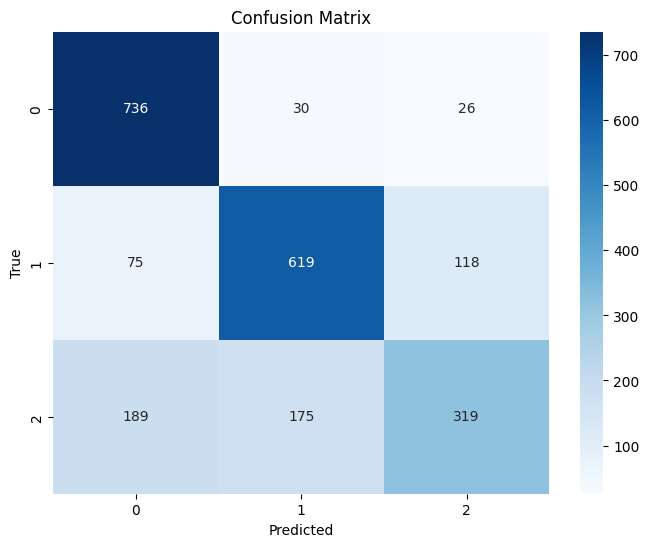

{'eval_loss': 0.7648345828056335,
 'eval_accuracy': 0.7319632706602536,
 'eval_f1': 0.719401040126269,
 'eval_precision': 0.7273607830167446,
 'eval_recall': 0.7319632706602536,
 'eval_runtime': 30.0508,
 'eval_samples_per_second': 76.105,
 'eval_steps_per_second': 9.517,
 'epoch': 1.0}

In [28]:
# FEVER Test-Set Evaluation using augmented data
trainer.evaluate(eval_dataset = tokenized_fever_data_augmented['test'])

              precision    recall  f1-score   support

           0       0.49      0.52      0.50       111
           1       0.54      0.53      0.54       116
           2       0.61      0.57      0.59       110

    accuracy                           0.54       337
   macro avg       0.55      0.54      0.54       337
weighted avg       0.55      0.54      0.54       337



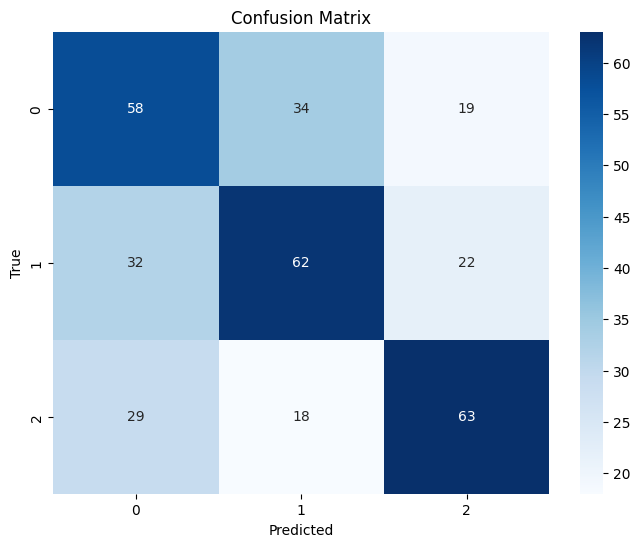

{'eval_loss': 1.3162816762924194,
 'eval_accuracy': 0.543026706231454,
 'eval_f1': 0.5438815853727647,
 'eval_precision': 0.5454693620741705,
 'eval_recall': 0.543026706231454,
 'eval_runtime': 4.9268,
 'eval_samples_per_second': 68.402,
 'eval_steps_per_second': 8.728,
 'epoch': 1.0}

In [29]:
# Adversarial Test-Set Evaluation using augmented data
trainer.evaluate(eval_dataset = tokenized_adversarial_test_data['test'])